# 04. 베이스라인 — 직접 만든 CNN

**이 노트북의 목적**

사전학습 없이 밑바닥부터 만든 CNN으로 기준선을 세운다. 이 숫자가 있어야 `05`의 전이학습이
얼마나 이득인지 말할 수 있다.

동시에 **클래스 불균형 대응 세 가지를 비교**한다.

| 실험 | 방법 | 근거 |
|---|---|---|
| `plain` | 아무 대응 없음 | 대조군 |
| `weighted` | `CrossEntropyLoss(weight=w)` | 손실에서 소수 클래스를 크게 벌점 |
| `sampler` | `WeightedRandomSampler` | 배치 구성 단계에서 균등하게 뽑음 |

`pro1`(헬멧)에서 `pos_weight`로 한 것이 `weighted`의 이진 버전이다. 12클래스에서는
클래스마다 가중치가 하나씩 나온다. `sampler`는 같은 목적을 다른 지점에서 시도하는 방법이라
함께 비교한다.

**실행 방법**: 아래 `SPLIT_TAG`를 `"v2"`로 한 번, `"v1"`으로 한 번, 총 두 번 돌린다.
결과는 `experiments.csv`에 누적되므로 덮어쓰기 걱정은 없다.

**출력물**: `models/baseline_{tag}_{exp}.pt`, `metrics/experiments.csv`, `figures/08~11*.png`

## 0. 설정

**GPU를 강제한다.** `pro1`~`pro3`은 `'cuda' if torch.cuda.is_available() else 'cpu'`를 썼는데,
CUDA 인식이 실패하면 조용히 CPU로 넘어가 그대로 학습이 진행된다. 3분짜리 에폭이 40분이 되고
30분 뒤에야 알아차리게 된다. 이 노트북은 실험이 6개(3종 × 2분할)라 손실이 크므로
`assert`로 첫 셀에서 멈추게 한다.

In [1]:
import os, json, time, copy, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, confusion_matrix,
                             classification_report, roc_auc_score)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "CUDA 미탐지 - 커널/드라이버를 확인하세요"
device = torch.device("cuda")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"

print(torch.__version__)
print(torch.cuda.get_device_name(0))

2.11.0+cu128
NVIDIA GeForce RTX 5060 Laptop GPU


### 실행 대상 선택

이 셀 하나만 바꿔서 두 번 돌린다. 나머지 코드는 손대지 않는다.

In [2]:
SPLIT_TAG = "v2"        # "v2" (그룹 인지) 또는 "v1" (단순 계층)

IMAGE_SIZE = 128
BATCH_SIZE = 64
EPOCHS     = 15
LR         = 1e-3
PATIENCE   = 5          # val macro-F1이 5에폭 개선 없으면 조기 종료

OUT = Path("outputs/garbage")
split     = pd.read_csv(OUT / "metrics" / f"split_{SPLIT_TAG}.csv")
label_map = json.load(open(OUT / "metrics" / "label_map.json", encoding="utf-8"))
nstats    = json.load(open(OUT / "metrics" / "norm_stats.json", encoding="utf-8"))
cw        = pd.read_csv(OUT / "metrics" / f"class_weights_{SPLIT_TAG}.csv")

classes   = [c for c, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
N_CLASSES = len(classes)

train_df = split[split.split == "train"].reset_index(drop=True)
val_df   = split[split.split == "val"].reset_index(drop=True)
test_df  = split[split.split == "test"].reset_index(drop=True)

DATA_MEAN = nstats[f"{SPLIT_TAG}_mean"]
DATA_STD  = nstats[f"{SPLIT_TAG}_std"]

print(f"분할 {SPLIT_TAG} | train {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}")
print(f"정규화 mean {DATA_MEAN} std {DATA_STD}")
print(f"클래스 {N_CLASSES}개")

분할 v2 | train 10,838 | val 2,323 | test 2,323
정규화 mean [0.6565, 0.6149, 0.5841] std [0.2807, 0.2913, 0.3051]
클래스 12개


## 1. 데이터셋과 증강

**`.convert("RGB")`는 필수다.** `01`에서 팔레트 모드(`P`) 파일이 존재하는 것을 확인했다.
그대로 텐서로 만들면 채널 수가 안 맞아 배치가 깨진다.

**증강은 train에만 적용한다.** val/test에 증강을 걸면 평가할 때마다 결과가 달라져 비교가 안 된다.
`pro2`가 증강 적용/미적용 이미지를 나란히 띄워 확인한 것과 같은 맥락이다.

**색은 건드리지 않는다.** `01`에서 유리 3종의 Hue 겹침 계수가 전부 0.5 미만으로 나왔다.
색이 곧 정답 신호라 `hue`를 흔들면 정답을 지우는 셈이 된다. 그래서 `hue=0.0`, `saturation=0.05`로
최소화하고 밝기·대비만 흔든다. 조명 차이는 실제로 존재하는 변동이지만 색상은 라벨 정보다.

In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.05, hue=0.0),   # 01의 색상 분석 결과 반영
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEAN, DATA_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEAN, DATA_STD),
])


class GarbageDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths  = frame["path"].tolist()
        self.labels = frame["label_idx"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")     # P 모드 대응 (01 참고)
        return self.transform(img), self.labels[i]


# Windows + Jupyter에서는 워커 프로세스가 spawn 방식으로 뜨면서
# __main__ 재임포트가 엉켜 로더 생성만 수십 분 걸리는 경우가 있다.
# 메인 프로세스에서 로딩해도 128px JPEG는 장당 1~2ms라 병목이 아니다.
NUM_WORKERS = 0

def make_loaders(sampler=None):
    common = dict(num_workers=NUM_WORKERS, pin_memory=True)
    if NUM_WORKERS > 0:
        common.update(persistent_workers=True, prefetch_factor=4)

    tr = DataLoader(GarbageDataset(train_df, train_tf),
                    batch_size=BATCH_SIZE,
                    shuffle=(sampler is None),
                    sampler=sampler,
                    drop_last=True,
                    **common)
    va = DataLoader(GarbageDataset(val_df, eval_tf),
                    batch_size=BATCH_SIZE, shuffle=False, **common)
    te = DataLoader(GarbageDataset(test_df, eval_tf),
                    batch_size=BATCH_SIZE, shuffle=False, **common)
    return tr, va, te


import time
t0 = time.time()
train_loader, val_loader, test_loader = make_loaders()
xb, yb = next(iter(train_loader))
print(f"로더 생성 + 첫 배치: {time.time() - t0:.1f}초  (5초 넘으면 문제)")
print(f"입력 배치 {tuple(xb.shape)} {xb.dtype}")
print(f"라벨 배치 {tuple(yb.shape)} {yb.dtype}")
print(f"값 범위 {xb.min():.3f} ~ {xb.max():.3f}")

로더 생성 + 첫 배치: 0.6초  (5초 넘으면 문제)
입력 배치 (64, 3, 128, 128) torch.float32
라벨 배치 (64,) torch.int64
값 범위 -2.339 ~ 1.363


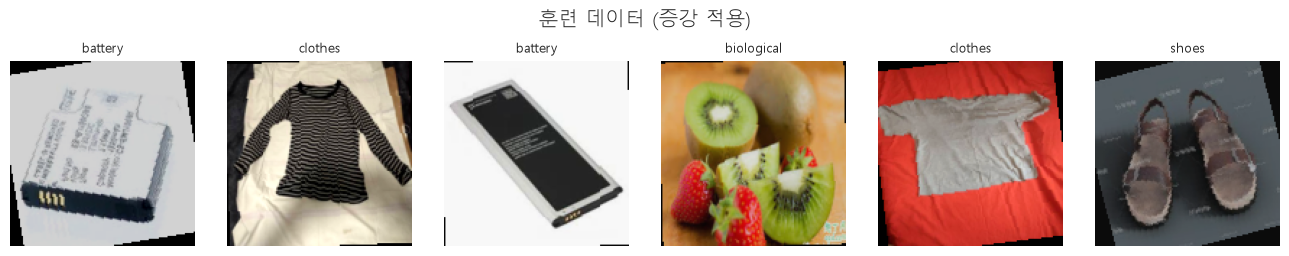

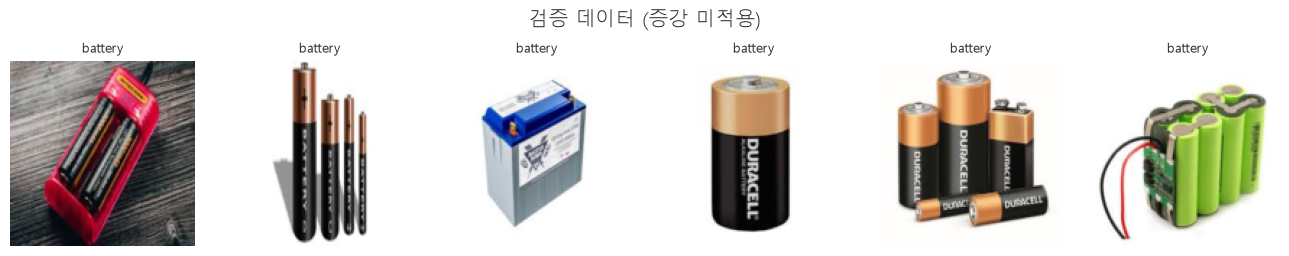

In [4]:
# 증강이 실제로 걸리는지 눈으로 확인 (pro2와 같은 점검)
def denormalize(t):
    mean = torch.tensor(DATA_MEAN).view(3, 1, 1)
    std  = torch.tensor(DATA_STD).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1)


def show_images(loader, n=6, title=""):
    images, labels = next(iter(loader))
    plt.figure(figsize=(2.2 * n, 2.6))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(denormalize(images[i]).permute(1, 2, 0).numpy())
        plt.title(classes[int(labels[i])], fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_images(train_loader, title="훈련 데이터 (증강 적용)")
show_images(val_loader,   title="검증 데이터 (증강 미적용)")

## 2. 모델

강의 `05_합성곱신경망`에서 배운 구성 그대로다. `Conv2d → BatchNorm2d → ReLU → MaxPool2d`를
한 블록으로 묶어 4번 쌓고, `AdaptiveAvgPool2d`로 크기를 고정한 뒤 분류기를 붙인다.

`pro1`의 `BaseCNN`은 `nn.Flatten()` 후 `Linear(512*10*10, 1024)`를 썼는데 파라미터가 5,712만 개였다.
여기서는 `AdaptiveAvgPool2d(1)`을 써서 42만 개 수준으로 줄인다. 데이터가 15,484장뿐이라
파라미터가 너무 많으면 과적합이 심해지기 때문이다.

**가중치 초기화**는 Kaiming(He)을 쓴다. ReLU 계열에 맞춰 설계된 초기화라 강의에서도
`nn.init.kaiming_normal_`을 ReLU와 짝지어 썼다.

In [5]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )


class GarbageCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, p_drop=0.3):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32),      # 128 -> 64
            conv_block(32, 64),     #  64 -> 32
            conv_block(64, 128),    #  32 -> 16
            conv_block(128, 256),   #  16 ->  8
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p_drop),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(128, n_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


_m = GarbageCNN()
print("GarbageCNN")
print(f"출력 모양: {tuple(_m(torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE)).shape)}")
print(f"전체 파라미터: {sum(p.numel() for p in _m.parameters()):,}")
del _m

GarbageCNN
출력 모양: (2, 12)
전체 파라미터: 423,340


## 3. 평가 · 학습 함수

`pro1`의 `evaluate` / `train_model` 인터페이스를 12클래스용으로 확장한다. 바뀐 곳은 세 군데다.

| `pro1` (이진) | 여기 (12클래스) |
|---|---|
| `torch.sigmoid` | `torch.softmax` |
| `BCEWithLogitsLoss` | `CrossEntropyLoss` |
| 체크포인트 선정 = val AUC | 체크포인트 선정 = **val macro-F1** |

**선정 지표를 macro-F1으로 바꾸는 이유**는 강의 `03_평가`에서 배운 그대로다. `clothes`가 전체의
34%라 정확도는 다수 클래스만 잘 맞혀도 높게 나오고 소수 클래스의 실패를 숨긴다. macro-F1은
클래스별 F1을 동등 가중으로 평균하므로 `brown-glass`를 통째로 틀리면 바로 떨어진다.

AUC도 함께 기록한다. `pro1`·`pro2`가 주 지표로 썼고, 다중분류에서는
`multi_class="ovr", average="macro"`로 확장할 수 있다.

In [6]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    losses, probs, trues = [], [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)
    preds = probs.argmax(axis=1)

    try:
        auc = roc_auc_score(trues, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")

    return {"loss":      sum(losses) / len(trues) if criterion is not None else None,
            "accuracy":  accuracy_score(trues, preds),
            "macro_f1":  f1_score(trues, preds, average="macro", zero_division=0),
            "macro_rec": recall_score(trues, preds, average="macro", zero_division=0),
            "macro_pre": precision_score(trues, preds, average="macro", zero_division=0),
            "auc":       auc,
            "probs": probs, "trues": trues, "preds": preds}

In [7]:
def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, criterion=None,
                ckpt_path="checkpoint.pt", label="model"):
    model = model.to(device)
    criterion = criterion or nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"loss": [], "val_loss": [], "accuracy": [],
               "val_accuracy": [], "val_macro_f1": [], "lr": []}
    best_f1, best_epoch, wait = -1.0, 0, 0

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, run_n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss    += loss.item() * len(yb)
            run_correct += (logits.argmax(1) == yb).sum().item()
            run_n       += len(yb)

        vm = evaluate(model, val_loader, criterion)
        cur_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        history["loss"].append(run_loss / run_n)
        history["accuracy"].append(run_correct / run_n)
        history["val_loss"].append(vm["loss"])
        history["val_accuracy"].append(vm["accuracy"])
        history["val_macro_f1"].append(vm["macro_f1"])
        history["lr"].append(cur_lr)

        mark = ""
        if vm["macro_f1"] > best_f1:
            best_f1, best_epoch, wait = vm["macro_f1"], epoch, 0
            torch.save(model.state_dict(), ckpt_path)
            mark = "저장"
        else:
            wait += 1

        print(f"[{label}] {epoch:2d}/{epochs} "
              f"loss {history['loss'][-1]:.4f} "
              f"val_loss {vm['loss']:.4f} "
              f"val_acc {vm['accuracy']:.4f} "
              f"val_f1 {vm['macro_f1']:.4f} "
              f"lr {cur_lr:.1e} ({time.time() - t0:.0f}s) {mark}")

        if wait >= PATIENCE:
            print(f"  조기 종료 - {PATIENCE}에폭 동안 개선 없음")
            break

    print(f"best val_macro_f1 = {best_f1:.4f} (epoch {best_epoch}) -> {ckpt_path}")
    history["best_macro_f1"] = best_f1
    history["best_epoch"] = best_epoch
    return history

In [8]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history["loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

    axes[1].plot(history["accuracy"], label="train")
    axes[1].plot(history["val_accuracy"], label="val")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

    axes[2].plot(history["val_macro_f1"], color="#c0392b")
    axes[2].axhline(history["best_macro_f1"], ls="--", color="gray")
    axes[2].set_title("Validation macro-F1"); axes[2].set_xlabel("epoch")

    for ax in axes:
        ax.grid(alpha=0.3)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_confusion(m, title="혼동행렬", save=None):
    cm = confusion_matrix(m["trues"], m["preds"])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(9, 7))
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes,
                annot_kws={"size": 8}, cbar_kws={"label": "행 기준 비율"})
    plt.xlabel("예측값"); plt.ylabel("실제값"); plt.title(title)
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150)
    plt.show()

## 4. 실험 1 — plain (대조군)

불균형에 아무 대응도 하지 않는다. 나머지 두 실험이 이 숫자보다 나아야 의미가 있다.

[plain]  1/15 loss 1.6816 val_loss 1.2917 val_acc 0.5463 val_f1 0.4201 lr 1.0e-03 (178s) 저장
[plain]  2/15 loss 1.4250 val_loss 1.1343 val_acc 0.6160 val_f1 0.5124 lr 9.9e-04 (175s) 저장
[plain]  3/15 loss 1.3113 val_loss 1.1315 val_acc 0.6268 val_f1 0.5362 lr 9.6e-04 (177s) 저장
[plain]  4/15 loss 1.2583 val_loss 1.0119 val_acc 0.6711 val_f1 0.5904 lr 9.0e-04 (179s) 저장
[plain]  5/15 loss 1.1931 val_loss 1.0885 val_acc 0.6281 val_f1 0.5097 lr 8.3e-04 (177s) 
[plain]  6/15 loss 1.1278 val_loss 0.9795 val_acc 0.6763 val_f1 0.6099 lr 7.5e-04 (177s) 저장
[plain]  7/15 loss 1.0890 val_loss 0.9357 val_acc 0.6905 val_f1 0.6152 lr 6.5e-04 (185s) 저장
[plain]  8/15 loss 1.0541 val_loss 0.8617 val_acc 0.7021 val_f1 0.6329 lr 5.5e-04 (182s) 저장
[plain]  9/15 loss 1.0101 val_loss 0.9104 val_acc 0.6991 val_f1 0.6446 lr 4.5e-04 (181s) 저장
[plain] 10/15 loss 0.9905 val_loss 0.8158 val_acc 0.7310 val_f1 0.6743 lr 3.5e-04 (187s) 저장
[plain] 11/15 loss 0.9547 val_loss 0.7835 val_acc 0.7378 val_f1 0.6816 lr 2.5e-04 

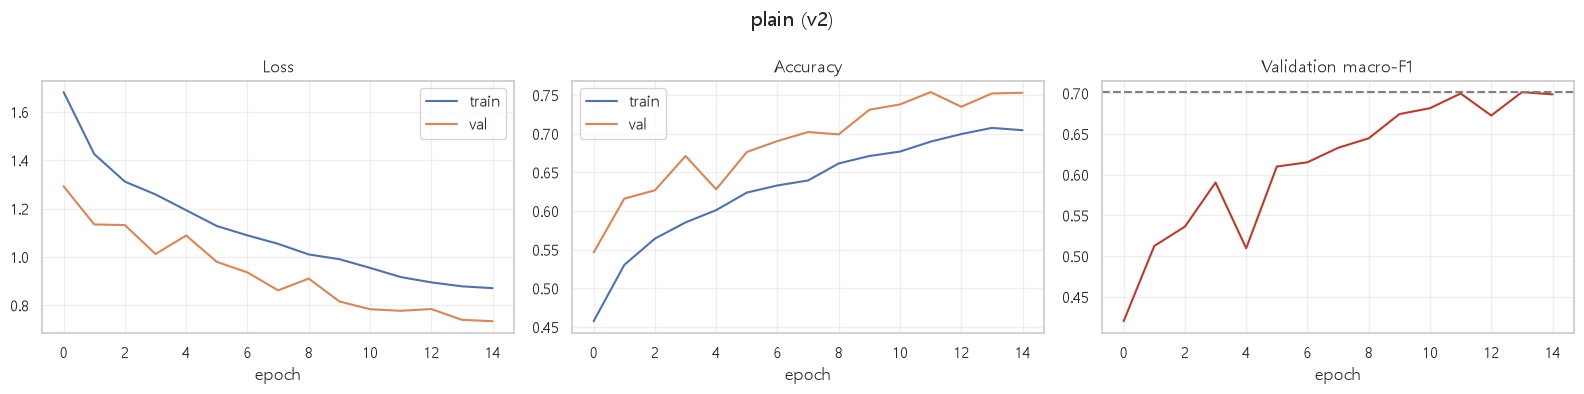

In [9]:
results = {}

train_loader, val_loader, test_loader = make_loaders()

model_plain = GarbageCNN()
hist_plain = train_model(model_plain, train_loader, val_loader,
                         ckpt_path=f"outputs/garbage/models/baseline_{SPLIT_TAG}_plain.pt",
                         label="plain")
results["plain"] = hist_plain
plot_history(hist_plain, f"plain ({SPLIT_TAG})")

## 5. 실험 2 — weighted (손실 가중치)

`03`에서 계산한 클래스 가중치를 `CrossEntropyLoss(weight=...)`에 넣는다.
소수 클래스를 틀렸을 때의 벌점이 커진다. `pro1`이 `pos_weight`로 한 것과 같은 방식이다.

클래스 가중치
  battery        1.3643
  biological     1.3127
  brown-glass    2.1251
  cardboard      1.4474
  clothes        0.2444
  green-glass    2.1004
  metal          1.6787
  paper          1.2305
  plastic        1.4928
  shoes          0.6401
  trash          1.8546
  white-glass    1.6787
[weighted]  1/15 loss 1.8964 val_loss 1.5986 val_acc 0.4361 val_f1 0.4110 lr 1.0e-03 (185s) 저장
[weighted]  2/15 loss 1.6055 val_loss 1.3673 val_acc 0.5730 val_f1 0.5067 lr 9.9e-04 (186s) 저장
[weighted]  3/15 loss 1.4988 val_loss 1.2915 val_acc 0.5854 val_f1 0.5390 lr 9.6e-04 (191s) 저장
[weighted]  4/15 loss 1.4300 val_loss 1.4333 val_acc 0.5088 val_f1 0.4893 lr 9.0e-04 (189s) 
[weighted]  5/15 loss 1.3519 val_loss 1.2896 val_acc 0.5566 val_f1 0.5161 lr 8.3e-04 (189s) 
[weighted]  6/15 loss 1.3092 val_loss 1.1920 val_acc 0.6009 val_f1 0.5824 lr 7.5e-04 (189s) 저장
[weighted]  7/15 loss 1.2563 val_loss 1.0912 val_acc 0.6509 val_f1 0.6150 lr 6.5e-04 (217s) 저장
[weighted]  8/15 loss 1.2186 val_loss 1.158

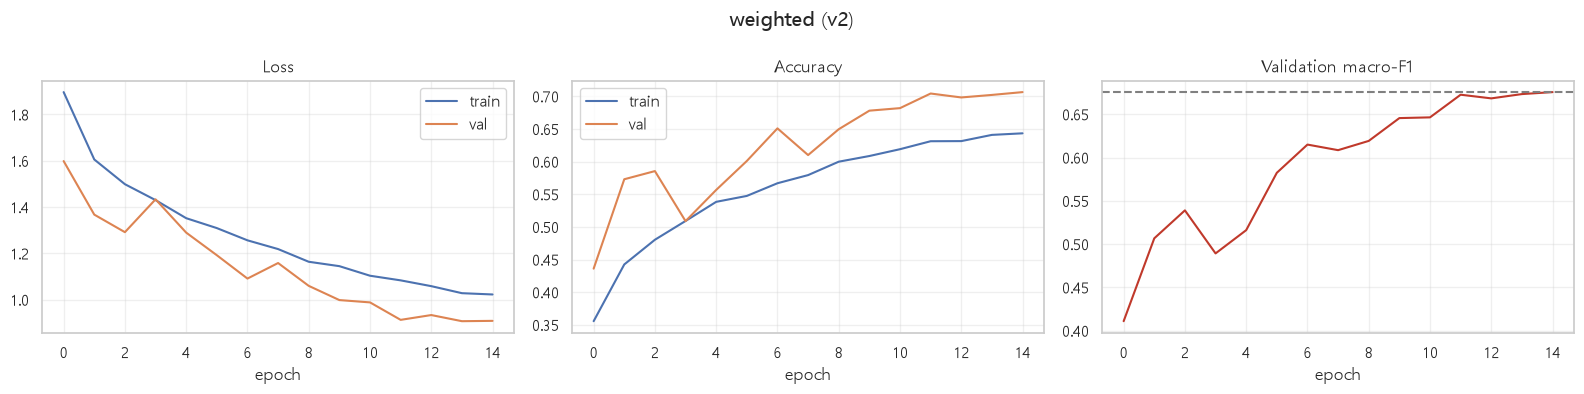

In [10]:
weights = torch.tensor(cw.sort_values("label_idx")["class_weight"].values,
                       dtype=torch.float32, device=device)
print("클래스 가중치")
for c, w in zip(classes, weights.cpu().numpy()):
    print(f"  {c:14s} {w:.4f}")

train_loader, val_loader, test_loader = make_loaders()

model_weighted = GarbageCNN()
hist_weighted = train_model(model_weighted, train_loader, val_loader,
                            criterion=nn.CrossEntropyLoss(weight=weights),
                            ckpt_path=f"outputs/garbage/models/baseline_{SPLIT_TAG}_weighted.pt",
                            label="weighted")
results["weighted"] = hist_weighted
plot_history(hist_weighted, f"weighted ({SPLIT_TAG})")

## 6. 실험 3 — sampler (배치 균등 추출)

손실이 아니라 **배치를 만드는 단계**에서 개입한다. 각 샘플에 자기 클래스의 역빈도를 확률로 주면
한 배치 안에 12클래스가 대체로 고르게 들어온다.

`weighted`와 목적은 같지만 지점이 다르다. `weighted`는 "틀리면 더 아프게", `sampler`는
"애초에 자주 보여주기"다. 어느 쪽이 나은지는 데이터마다 다르므로 직접 비교한다.

샘플러 적용 배치의 클래스 분포: [7 5 4 7 6 1 6 7 6 4 7 4]
[sampler]  1/15 loss 1.8358 val_loss 1.5626 val_acc 0.4873 val_f1 0.4192 lr 1.0e-03 (246s) 저장
[sampler]  2/15 loss 1.5361 val_loss 1.3661 val_acc 0.5303 val_f1 0.4961 lr 9.9e-04 (265s) 저장
[sampler]  3/15 loss 1.4474 val_loss 1.3337 val_acc 0.5682 val_f1 0.5168 lr 9.6e-04 (270s) 저장
[sampler]  4/15 loss 1.3568 val_loss 1.2368 val_acc 0.5936 val_f1 0.5572 lr 9.0e-04 (177s) 저장
[sampler]  5/15 loss 1.3026 val_loss 1.0945 val_acc 0.6380 val_f1 0.6075 lr 8.3e-04 (175s) 저장
[sampler]  6/15 loss 1.2290 val_loss 1.1671 val_acc 0.6108 val_f1 0.5828 lr 7.5e-04 (177s) 
[sampler]  7/15 loss 1.1995 val_loss 1.1071 val_acc 0.6289 val_f1 0.6004 lr 6.5e-04 (176s) 
[sampler]  8/15 loss 1.1395 val_loss 1.0699 val_acc 0.6410 val_f1 0.6116 lr 5.5e-04 (176s) 저장
[sampler]  9/15 loss 1.1084 val_loss 0.9920 val_acc 0.6560 val_f1 0.6353 lr 4.5e-04 (176s) 저장
[sampler] 10/15 loss 1.0695 val_loss 0.9254 val_acc 0.6926 val_f1 0.6551 lr 3.5e-04 (175s) 저장
[sampler] 11/15 los

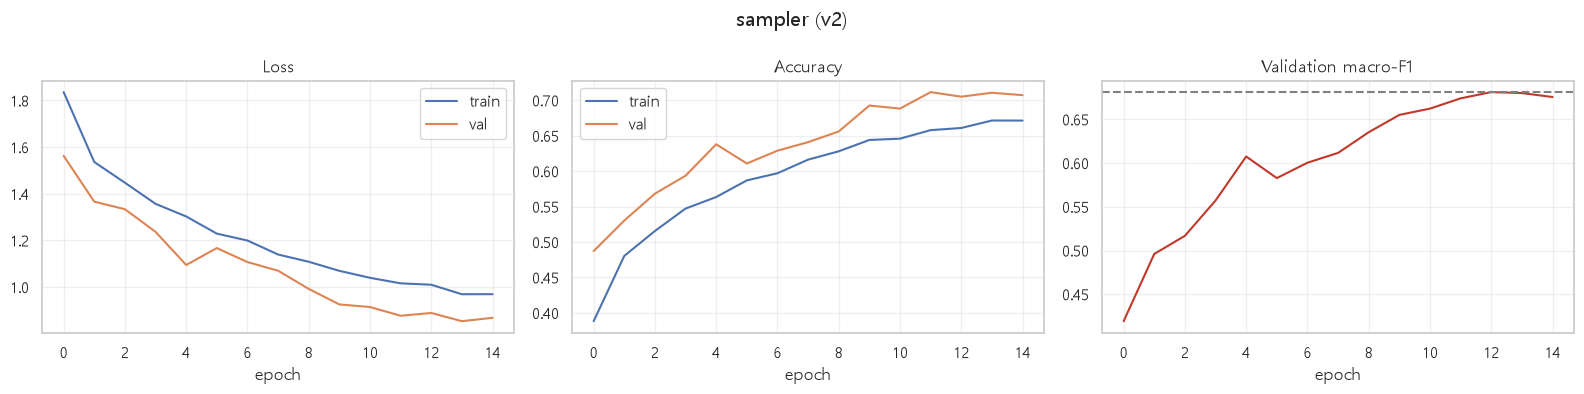

In [11]:
counts = train_df["label_idx"].value_counts().sort_index().values
sample_w = np.array([1.0 / counts[i] for i in train_df["label_idx"]], dtype=np.float64)

sampler = WeightedRandomSampler(weights=torch.from_numpy(sample_w),
                                num_samples=len(train_df),
                                replacement=True)

train_loader_s, val_loader, test_loader = make_loaders(sampler=sampler)

# 배치가 실제로 균등해졌는지 확인
_, ybs = next(iter(train_loader_s))
print("샘플러 적용 배치의 클래스 분포:", np.bincount(ybs.numpy(), minlength=N_CLASSES))

model_sampler = GarbageCNN()
hist_sampler = train_model(model_sampler, train_loader_s, val_loader,
                           ckpt_path=f"outputs/garbage/models/baseline_{SPLIT_TAG}_sampler.pt",
                           label="sampler")
results["sampler"] = hist_sampler
plot_history(hist_sampler, f"sampler ({SPLIT_TAG})")

## 7. 세 실험 비교

**val로만 비교한다.** test는 `06`에서 최종 모델 하나에만 딱 한 번 쓴다. 여러 후보를 test로
비교해서 고르면 test가 사실상 검증셋이 되어 버리고, 보고하는 성능이 낙관적으로 편향된다.
강의 `4_8`이 지적한 것과 같은 구조의 누수다.

In [12]:
rows = []
for name, h in results.items():
    rows.append({"split": SPLIT_TAG,
                 "model": "GarbageCNN",
                 "exp": name,
                 "best_epoch": h["best_epoch"],
                 "val_macro_f1": round(h["best_macro_f1"], 4),
                 "val_accuracy": round(h["val_accuracy"][h["best_epoch"] - 1], 4),
                 "val_loss": round(h["val_loss"][h["best_epoch"] - 1], 4),
                 "epochs_run": len(h["loss"])})

exp_df = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
print(exp_df.to_string(index=False))

best_exp = exp_df.iloc[0]["exp"]
print(f"\n최고 실험: {best_exp} (val macro-F1 {exp_df.iloc[0]['val_macro_f1']:.4f})")

split      model      exp  best_epoch  val_macro_f1  val_accuracy  val_loss  epochs_run
   v2 GarbageCNN    plain          14        0.7013        0.7520    0.7397          15
   v2 GarbageCNN  sampler          13        0.6811        0.7051    0.8888          15
   v2 GarbageCNN weighted          15        0.6756        0.7064    0.9085          15

최고 실험: plain (val macro-F1 0.7013)


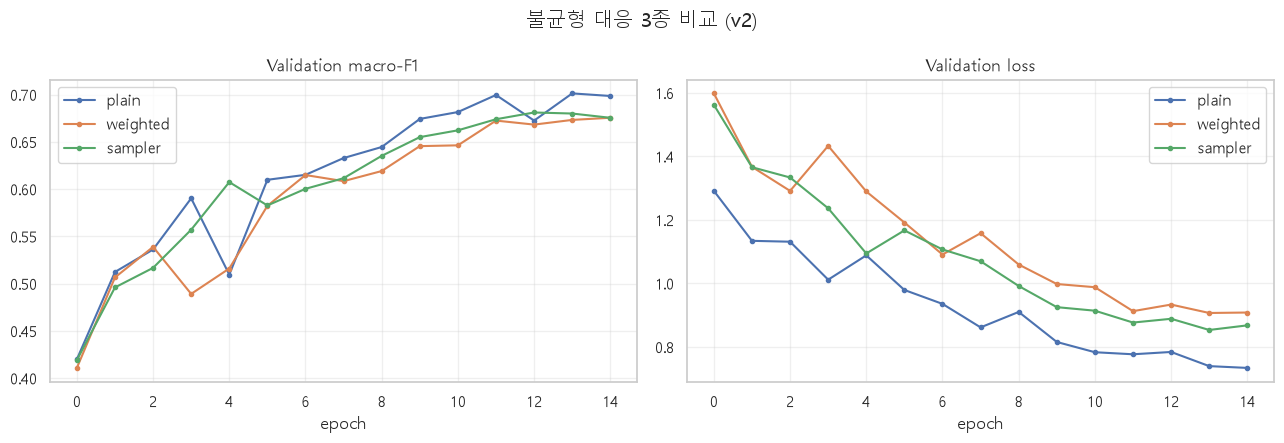

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, h in results.items():
    axes[0].plot(h["val_macro_f1"], label=name, marker="o", ms=3)
    axes[1].plot(h["val_loss"], label=name, marker="o", ms=3)

axes[0].set_title("Validation macro-F1"); axes[0].set_xlabel("epoch")
axes[1].set_title("Validation loss"); axes[1].set_xlabel("epoch")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f"불균형 대응 3종 비교 ({SPLIT_TAG})")
plt.tight_layout()
plt.savefig(OUT / "figures" / f"08_baseline_compare_{SPLIT_TAG}.png", dpi=150)
plt.show()

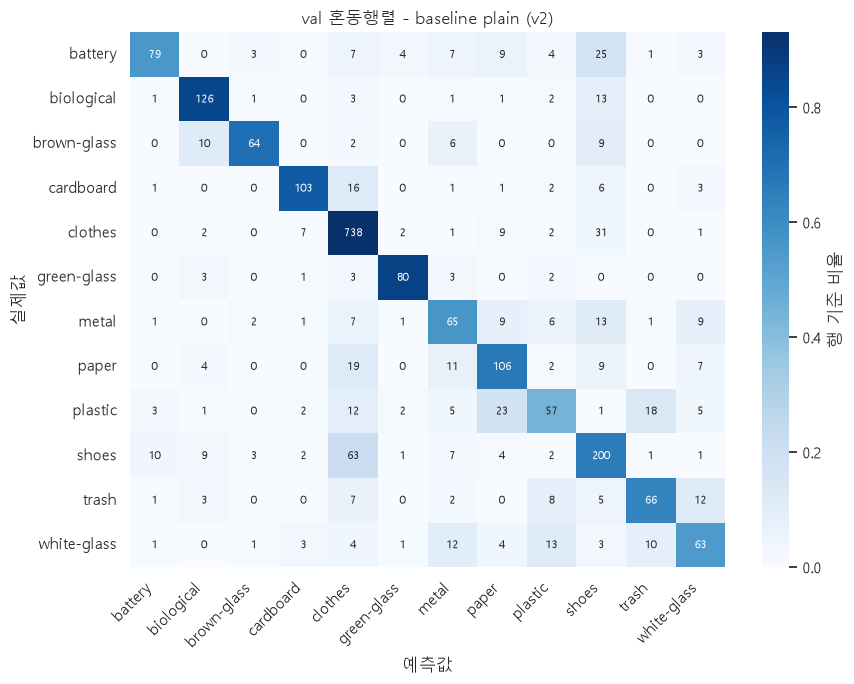

              precision    recall  f1-score   support

     battery     0.8144    0.5563    0.6611       142
  biological     0.7975    0.8514    0.8235       148
 brown-glass     0.8649    0.7033    0.7758        91
   cardboard     0.8655    0.7744    0.8175       133
     clothes     0.8377    0.9306    0.8817       793
 green-glass     0.8791    0.8696    0.8743        92
       metal     0.5372    0.5652    0.5508       115
       paper     0.6386    0.6709    0.6543       158
     plastic     0.5700    0.4419    0.4978       129
       shoes     0.6349    0.6601    0.6472       303
       trash     0.6804    0.6346    0.6567       104
 white-glass     0.6058    0.5478    0.5753       115

    accuracy                         0.7520      2323
   macro avg     0.7272    0.6838    0.7013      2323
weighted avg     0.7497    0.7520    0.7474      2323

accuracy 0.7520 | macro-F1 0.7013 | AUC 0.9656


In [14]:
# 최고 실험의 val 혼동행렬과 클래스별 성능
best_model = GarbageCNN().to(device)
best_model.load_state_dict(
    torch.load(f"outputs/garbage/models/baseline_{SPLIT_TAG}_{best_exp}.pt",
               map_location=device))

mv = evaluate(best_model, val_loader, nn.CrossEntropyLoss())
plot_confusion(mv, f"val 혼동행렬 - baseline {best_exp} ({SPLIT_TAG})",
               save=OUT / "figures" / f"09_baseline_cm_{SPLIT_TAG}.png")

print(classification_report(mv["trues"], mv["preds"],
                            target_names=classes, digits=4, zero_division=0))
print(f"accuracy {mv['accuracy']:.4f} | macro-F1 {mv['macro_f1']:.4f} | AUC {mv['auc']:.4f}")

### 정확도와 macro-F1의 격차

위 출력에서 `accuracy`와 `macro avg`의 f1-score를 비교해보자. 정확도가 더 높다면
그 차이만큼 **소수 클래스가 다수 클래스보다 못 맞고 있다**는 뜻이다.

강의 `pro3`(Cityscapes)에서 픽셀 정확도 0.7405인데 mIoU가 0.1549였던 것과 같은 현상이다.
그쪽은 클래스가 35개에 railtrack·bicycle 등이 IoU 0.0이라 격차가 5배 가까이 벌어졌다.
격차의 크기는 다르지만 **다수 클래스에 지배되는 지표와 클래스 균등 지표의 차이**라는 점은 같다.

In [16]:
# experiments.csv에 누적 저장 (v1, v2 결과를 한 파일에 모은다)
REQUIRED = ["split", "model", "exp", "best_epoch",
            "val_macro_f1", "val_accuracy", "val_loss", "epochs_run"]

exp_path = OUT / "metrics" / "experiments.csv"
exp_df_all = exp_df

if exp_path.exists():
    prev = pd.read_csv(exp_path)
    if set(REQUIRED).issubset(prev.columns):
        # 같은 split + 같은 model 행만 교체하고 나머지는 유지
        prev = prev[~((prev["split"] == SPLIT_TAG) & (prev["model"] == "GarbageCNN"))]
        exp_df_all = pd.concat([prev[REQUIRED], exp_df[REQUIRED]], ignore_index=True)
    else:
        # 이전 파이프라인이 만든 구버전 파일 -> 백업 후 새로 시작
        backup = exp_path.with_name("experiments_old.csv")
        exp_path.rename(backup)
        print(f"구버전 experiments.csv 발견 (열: {list(prev.columns)})")
        print(f"  -> {backup.name} 으로 옮기고 새로 만듭니다")

exp_df_all.to_csv(exp_path, index=False, encoding="utf-8")
print(f"\nexperiments.csv 저장 ({len(exp_df_all)}행)")
print(exp_df_all.to_string(index=False))

구버전 experiments.csv 발견 (열: ['strategy', 'val_acc', 'macro_f1', 'min_recall', 'worst_class', 'recall_std', 'minutes', 'model', 'img_size', 'epochs'])
  -> experiments_old.csv 으로 옮기고 새로 만듭니다

experiments.csv 저장 (3행)
split      model      exp  best_epoch  val_macro_f1  val_accuracy  val_loss  epochs_run
   v2 GarbageCNN    plain          14        0.7013        0.7520    0.7397          15
   v2 GarbageCNN  sampler          13        0.6811        0.7051    0.8888          15
   v2 GarbageCNN weighted          15        0.6756        0.7064    0.9085          15


In [17]:
from sklearn.metrics import recall_score
for name in ["plain", "weighted", "sampler"]:
    m = GarbageCNN().to(device)
    m.load_state_dict(torch.load(
        f"outputs/garbage/models/baseline_{SPLIT_TAG}_{name}.pt", map_location=device))
    r = evaluate(m, val_loader)
    rec = recall_score(r["trues"], r["preds"], average=None, zero_division=0)
    print(f"{name:9s} 최저 recall {rec.min():.4f} ({classes[rec.argmin()]}) "
          f"| recall 표준편차 {rec.std():.4f}")

plain     최저 recall 0.4419 (plastic) | recall 표준편차 0.1422
weighted  최저 recall 0.4341 (plastic) | recall 표준편차 0.1529
sampler   최저 recall 0.4806 (plastic) | recall 표준편차 0.1370


## 정리

| 항목 | 내용 |
|---|---|
| 모델 | `GarbageCNN` (Conv-BN-ReLU-Pool × 4 + AdaptiveAvgPool) |
| 선정 지표 | **val macro-F1** (정확도 아님) |
| 비교 실험 | plain / weighted / sampler |
| test 사용 | 없음 — `06`에서 한 번만 |

**두 번 돌리는 것을 잊지 말 것.** `SPLIT_TAG`를 `"v2"`와 `"v1"`으로 각각 실행해야
`06`에서 누수 영향을 비교할 수 있다. `experiments.csv`는 덮어쓰지 않고 누적된다.

**다음 단계**: 여기서 나온 숫자는 사전학습 없이 15,484장만으로 얻은 것이다. ImageNet에서
미리 학습된 특징을 가져오면 얼마나 달라지는지 본다.

→ `05_Transfer.ipynb`